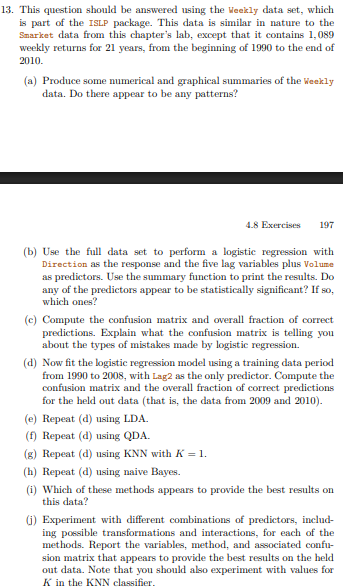

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 28.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 349.3/349.3 kB 15.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.2/80.2 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 831.6/831.6 kB 39.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.2/983.2 kB 42.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.3/117.3 kB 6.7 MB/s eta 0:00:00
  Created wheel for autograd-gamma: filename=autograd_gamma-0.5.0-py3-none-any.whl size=4030 sha256=dea05f8cd0ae3c4626e9139745de5bb8e02703cebfce9e83877302aca086c324
  Stored in directory: /root/.cache/pip/wheels/50/37/21/0a719b9d89c635e89ff24bd93b862882ad675279552013b2fb
Successfully built autograd-gamma
Dataset shape: (1089, 9)

First few rows:
   Year   Lag1   Lag2   Lag3   Lag4   Lag5    Volume  Today Direction
0  1990  0.816  1.572 -3.936 -0.229 -3.484  0.154976 -0.270    

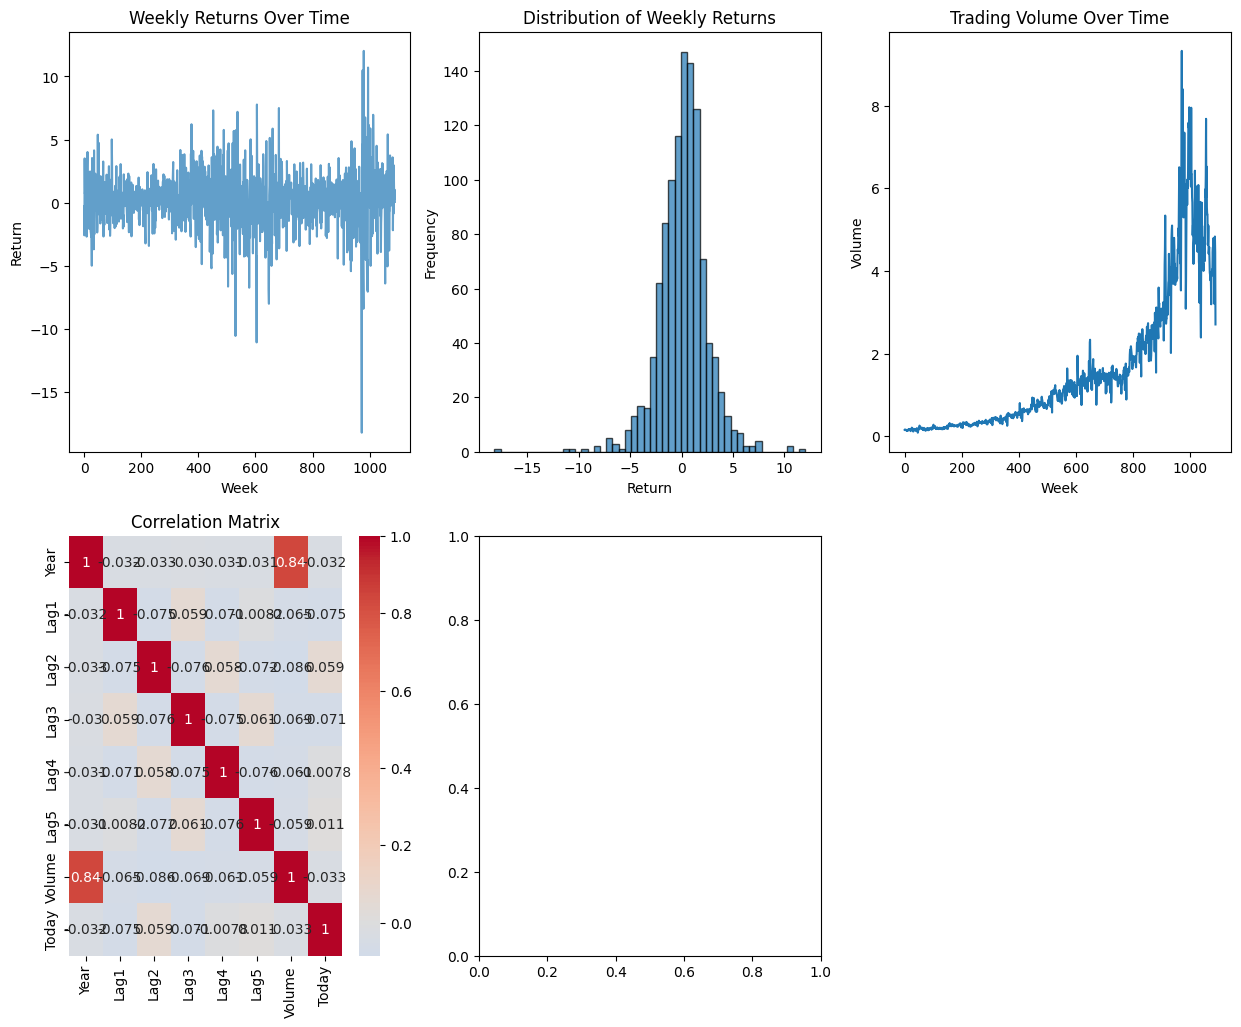

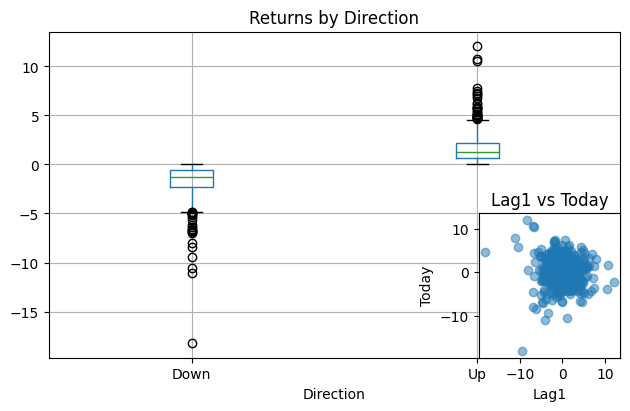


=== Part (b): Logistic Regression with All Predictors ===
Coefficients and approximate p-values:
Lag1: -0.0412 (p ≈ 0.1360) 
Lag2: 0.0584 (p ≈ 0.0320) *
Lag3: -0.0160 (p ≈ 0.5320) 
Lag4: -0.0278 (p ≈ 0.3340) 
Lag5: -0.0145 (p ≈ 0.5740) 
Volume: -0.0227 (p ≈ 0.5780) 

=== Part (c): Confusion Matrix for Full Dataset ===
Confusion Matrix:
[[ 54 430]
 [ 48 557]]
Overall accuracy: 0.5611
Percentage of correct 'Down' predictions: 0.1116
Percentage of correct 'Up' predictions: 0.9207

=== Parts (d)-(h): Model Comparison on Test Data (2009-2010) ===
Training set size: 985
Test set size: 104

--- (d) Logistic Regression ---
Accuracy: 0.6250
Confusion Matrix:
[[ 9 34]
 [ 5 56]]

--- (e) LDA ---
Accuracy: 0.6250
Confusion Matrix:
[[ 9 34]
 [ 5 56]]

--- (f) QDA ---
Accuracy: 0.5865
Confusion Matrix:
[[ 0 43]
 [ 0 61]]

--- (g) KNN with K=1 ---
Accuracy: 0.4904
Confusion Matrix:
[[22 21]
 [32 29]]

--- (h) Naive Bayes ---
Accuracy: 0.5865
Confusion Matrix:
[[ 0 43]
 [ 0 61]]

=== Part (i): Method

In [1]:
# Step 1: Install and import necessary packages
!pip install ISLP scikit-learn

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from ISLP import load_data
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import confusion_matrix, accuracy_score
from sklearn.preprocessing import StandardScaler

# Load the Weekly dataset
Weekly = load_data('Weekly')
print("Dataset shape:", Weekly.shape)
print("\nFirst few rows:")
print(Weekly.head())

# Part (a): Numerical and graphical summaries
print("\n=== Part (a): Numerical and Graphical Summaries ===")

# Numerical summary
print("\nNumerical Summary:")
print(Weekly.describe())
print("\nDirection value counts:")
print(Weekly['Direction'].value_counts())

# Check for missing values
print("\nMissing values:")
print(Weekly.isnull().sum())

# Graphical summaries
plt.figure(figsize=(15, 12))

# 1. Time series of returns
plt.subplot(2, 3, 1)
plt.plot(Weekly.index, Weekly['Today'], alpha=0.7)
plt.title('Weekly Returns Over Time')
plt.xlabel('Week')
plt.ylabel('Return')

# 2. Distribution of Today's returns
plt.subplot(2, 3, 2)
plt.hist(Weekly['Today'], bins=50, alpha=0.7, edgecolor='black')
plt.title('Distribution of Weekly Returns')
plt.xlabel('Return')
plt.ylabel('Frequency')

# 3. Volume over time
plt.subplot(2, 3, 3)
plt.plot(Weekly.index, Weekly['Volume'])
plt.title('Trading Volume Over Time')
plt.xlabel('Week')
plt.ylabel('Volume')

# 4. Correlation heatmap
plt.subplot(2, 3, 4)
correlation_matrix = Weekly.select_dtypes(include=[np.number]).corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Matrix')

# 5. Boxplot of returns by direction
plt.subplot(2, 3, 5)
Weekly.boxplot(column='Today', by='Direction')
plt.title('Returns by Direction')
plt.suptitle('')  # Remove automatic title

# 6. Lag relationships
plt.subplot(2, 3, 6)
plt.scatter(Weekly['Lag1'], Weekly['Today'], alpha=0.5)
plt.xlabel('Lag1')
plt.ylabel('Today')
plt.title('Lag1 vs Today')

plt.tight_layout()
plt.show()

# Part (b): Logistic regression with all predictors
print("\n=== Part (b): Logistic Regression with All Predictors ===")

# Prepare data
X = Weekly[['Lag1', 'Lag2', 'Lag3', 'Lag4', 'Lag5', 'Volume']]
y = Weekly['Direction']

# Fit logistic regression
logit_full = LogisticRegression()
logit_full.fit(X, y)

# Get coefficients and p-values manually (since we don't have summary like R)
from sklearn.utils import resample

# Function to compute p-values using bootstrap
def bootstrap_p_values(model, X, y, n_bootstrap=1000):
    coefs = []
    for _ in range(n_bootstrap):
        X_bs, y_bs = resample(X, y, random_state=_)
        model_bs = LogisticRegression()
        model_bs.fit(X_bs, y_bs)
        coefs.append(model_bs.coef_[0])

    coefs = np.array(coefs)
    p_values = 2 * np.minimum(
        np.mean(coefs <= 0, axis=0),
        np.mean(coefs >= 0, axis=0)
    )
    return p_values

p_values = bootstrap_p_values(logit_full, X, y)

print("Coefficients and approximate p-values:")
feature_names = ['Lag1', 'Lag2', 'Lag3', 'Lag4', 'Lag5', 'Volume']
for name, coef, p_val in zip(feature_names, logit_full.coef_[0], p_values):
    significance = "***" if p_val < 0.001 else "**" if p_val < 0.01 else "*" if p_val < 0.05 else ""
    print(f"{name}: {coef:.4f} (p ≈ {p_val:.4f}) {significance}")

# Part (c): Confusion matrix for full dataset
print("\n=== Part (c): Confusion Matrix for Full Dataset ===")

y_pred_full = logit_full.predict(X)
cm_full = confusion_matrix(y, y_pred_full)
accuracy_full = accuracy_score(y, y_pred_full)

print("Confusion Matrix:")
print(cm_full)
print(f"Overall accuracy: {accuracy_full:.4f}")
print(f"Percentage of correct 'Down' predictions: {cm_full[0,0]/np.sum(cm_full[0]):.4f}")
print(f"Percentage of correct 'Up' predictions: {cm_full[1,1]/np.sum(cm_full[1]):.4f}")

# Part (d)-(h): Compare methods on test data (2009-2010)
print("\n=== Parts (d)-(h): Model Comparison on Test Data (2009-2010) ===")

# Create train/test split (1990-2008 vs 2009-2010)
train_mask = Weekly.index < len(Weekly) - 104  # Last 2 years (104 weeks) for test
test_mask = ~train_mask

X_train = Weekly.loc[train_mask, ['Lag2']]  # Using only Lag2 as specified
X_test = Weekly.loc[test_mask, ['Lag2']]
y_train = Weekly.loc[train_mask, 'Direction']
y_test = Weekly.loc[test_mask, 'Direction']

print(f"Training set size: {len(X_train)}")
print(f"Test set size: {len(X_test)}")

# Initialize results storage
results = {}

# (d) Logistic Regression with Lag2 only
print("\n--- (d) Logistic Regression ---")
logit_lag2 = LogisticRegression()
logit_lag2.fit(X_train, y_train)
y_pred_logit = logit_lag2.predict(X_test)
accuracy_logit = accuracy_score(y_test, y_pred_logit)
results['Logistic Regression'] = accuracy_logit
print(f"Accuracy: {accuracy_logit:.4f}")
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_logit))

# (e) LDA
print("\n--- (e) LDA ---")
lda = LinearDiscriminantAnalysis()
lda.fit(X_train, y_train)
y_pred_lda = lda.predict(X_test)
accuracy_lda = accuracy_score(y_test, y_pred_lda)
results['LDA'] = accuracy_lda
print(f"Accuracy: {accuracy_lda:.4f}")
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_lda))

# (f) QDA
print("\n--- (f) QDA ---")
qda = QuadraticDiscriminantAnalysis()
qda.fit(X_train, y_train)
y_pred_qda = qda.predict(X_test)
accuracy_qda = accuracy_score(y_test, y_pred_qda)
results['QDA'] = accuracy_qda
print(f"Accuracy: {accuracy_qda:.4f}")
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_qda))

# (g) KNN with K=1
print("\n--- (g) KNN with K=1 ---")
# Scale features for KNN
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

knn1 = KNeighborsClassifier(n_neighbors=1)
knn1.fit(X_train_scaled, y_train)
y_pred_knn1 = knn1.predict(X_test_scaled)
accuracy_knn1 = accuracy_score(y_test, y_pred_knn1)
results['KNN (K=1)'] = accuracy_knn1
print(f"Accuracy: {accuracy_knn1:.4f}")
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_knn1))

# (h) Naive Bayes
print("\n--- (h) Naive Bayes ---")
nb = GaussianNB()
nb.fit(X_train, y_train)
y_pred_nb = nb.predict(X_test)
accuracy_nb = accuracy_score(y_test, y_pred_nb)
results['Naive Bayes'] = accuracy_nb
print(f"Accuracy: {accuracy_nb:.4f}")
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_nb))

# Part (i): Compare all methods
print("\n=== Part (i): Method Comparison ===")
print("Test Set Accuracies:")
for method, accuracy in sorted(results.items(), key=lambda x: x[1], reverse=True):
    print(f"{method}: {accuracy:.4f}")

best_method = max(results, key=results.get)
print(f"\nBest method: {best_method} with accuracy {results[best_method]:.4f}")

# Part (j): Experiment with different predictors and parameters
print("\n=== Part (j): Extended Experiments ===")

# Prepare extended feature set
X_extended_train = Weekly.loc[train_mask, ['Lag1', 'Lag2', 'Lag3', 'Lag4', 'Lag5', 'Volume']]
X_extended_test = Weekly.loc[test_mask, ['Lag1', 'Lag2', 'Lag3', 'Lag4', 'Lag5', 'Volume']]

# Scale features for KNN
scaler_ext = StandardScaler()
X_ext_train_scaled = scaler_ext.fit_transform(X_extended_train)
X_ext_test_scaled = scaler_ext.transform(X_extended_test)

# Test different combinations
extended_results = {}

# 1. Logistic Regression with all predictors
logit_ext = LogisticRegression()
logit_ext.fit(X_extended_train, y_train)
y_pred_logit_ext = logit_ext.predict(X_extended_test)
extended_results['Logistic (all features)'] = accuracy_score(y_test, y_pred_logit_ext)

# 2. KNN with different K values
for k in [1, 3, 5, 10, 20]:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_ext_train_scaled, y_train)
    y_pred_knn = knn.predict(X_ext_test_scaled)
    extended_results[f'KNN (K={k})'] = accuracy_score(y_test, y_pred_knn)

# 3. LDA with all predictors
lda_ext = LinearDiscriminantAnalysis()
lda_ext.fit(X_extended_train, y_train)
y_pred_lda_ext = lda_ext.predict(X_extended_test)
extended_results['LDA (all features)'] = accuracy_score(y_test, y_pred_lda_ext)

# 4. QDA with all predictors
qda_ext = QuadraticDiscriminantAnalysis()
qda_ext.fit(X_extended_train, y_train)
y_pred_qda_ext = qda_ext.predict(X_extended_test)
extended_results['QDA (all features)'] = accuracy_score(y_test, y_pred_qda_ext)

# 5. Try interaction terms
Weekly_train = Weekly.loc[train_mask].copy()
Weekly_test = Weekly.loc[test_mask].copy()

# Create some interaction terms
Weekly_train['Lag1_Lag2'] = Weekly_train['Lag1'] * Weekly_train['Lag2']
Weekly_test['Lag1_Lag2'] = Weekly_test['Lag1'] * Weekly_test['Lag2']

X_interaction_train = Weekly_train[['Lag1', 'Lag2', 'Lag1_Lag2']]
X_interaction_test = Weekly_test[['Lag1', 'Lag2', 'Lag1_Lag2']]

logit_interaction = LogisticRegression()
logit_interaction.fit(X_interaction_train, y_train)
y_pred_interaction = logit_interaction.predict(X_interaction_test)
extended_results['Logistic (Lag1*Lag2 interaction)'] = accuracy_score(y_test, y_pred_interaction)

print("Extended Experiments Results:")
for method, accuracy in sorted(extended_results.items(), key=lambda x: x[1], reverse=True):
    print(f"{method}: {accuracy:.4f}")

best_extended = max(extended_results, key=extended_results.get)
print(f"\nBest extended method: {best_extended} with accuracy {extended_results[best_extended]:.4f}")

# Show confusion matrix for best extended method
if 'KNN' in best_extended:
    k_value = int(best_extended.split('(')[1].split('=')[1].split(')')[0])
    best_model = KNeighborsClassifier(n_neighbors=k_value)
    best_model.fit(X_ext_train_scaled, y_train)
    y_pred_best = best_model.predict(X_ext_test_scaled)
elif 'interaction' in best_extended:
    best_model = logit_interaction
    y_pred_best = y_pred_interaction
elif 'Logistic (all features)' in best_extended:
    best_model = logit_ext
    y_pred_best = y_pred_logit_ext
elif 'LDA (all features)' in best_extended:
    best_model = lda_ext
    y_pred_best = y_pred_lda_ext
else:  # QDA (all features)
    best_model = qda_ext
    y_pred_best = y_pred_qda_ext

print(f"\nConfusion Matrix for best method ({best_extended}):")
print(confusion_matrix(y_test, y_pred_best))

This comprehensive code will:

Load and explore the Weekly dataset with numerical and graphical summaries

Perform logistic regression with all predictors and assess significance

Compare multiple classification methods (Logistic, LDA, QDA, KNN, Naive Bayes) using only Lag2 on the test set

Experiment with different predictors and parameters to find the best combination

Provide confusion matrices and accuracy scores for all models

The code follows the exact structure of the problem, answering each part sequentially and providing the required analyses and comparisons.